# Task
The mini-project is a critical component of this course. The work should reflect students’ understanding of certain topics beyond the level/scope covered in lectures. Two students will form a team to solve a password strength classification problem. The project offers a hands-on opportunity for students to apply their knowledge, and showcase their problem-solving skills in the realm of machine learning and data analysis.

Details

Provided is a dataset called password_Set1.csv, which contains a list of passwords together with their respective strength levels. The dataset contains two columns: the password string and an integer indicating its strength level.  Specifically, the strength levels are categorized as follows:
	0: very weak passwords
	1: weak passwords
	2: average passwords
	3: strong passwords
	4: very strong passwords

The objective is to develop a machine learning model capable of accurately discerning the strength level of any user-input password.

In a typical machine learning pipeline, the initial step involves conducting an exploratory data analysis to gain insights into the dataset. Your team can decide whether machine learning algorithms or deep learning algorithms is used to solve the problem.

If your team intends to use machine learning algorithm, you can explore the type of feature used to characterize the strength of the password. If your team intends to use deep learning, embedding techniques can be explored.

You can use the machine learning/deep learning techniques you learn from the lecture to solve the problem.

kNN (k=)
Logistic regression
Decision tree Random forest
(no of tree=?)
Support vector machine (C=)


Here is all the data you need:
"password_Set1.csv"

## Data loading

### Subtask:
Load the password data from the provided CSV file into a pandas DataFrame.


**Reasoning**:
Load the password data from the provided CSV file into a pandas DataFrame and display its first few rows, last few rows, and shape to verify the data is loaded correctly.



In [1]:
import pandas as pd

try:
    df_password = pd.read_csv('password_Set1.csv')
    display(df_password.head())
    display(df_password.tail())
    print(df_password.shape)
except FileNotFoundError:
    print("Error: 'password_Set1.csv' not found.")
except pd.errors.ParserError:
    print("Error: Could not parse the CSV file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,password,strength
0,fofsl,0
1,qabiogenous&,2
2,ppppabhorrer2,1
3,nmbnm,0
4,acinaces2abc,1


,password,strength
30045,!bacondylose,2
30046,5abashedtyui,1
30047,ssssadsessor,1
30048,ovss1,0
30049,-EQ`F[wl_66pD#{<~>;<='xEg82,4


(30050, 2)


## Data exploration

### Subtask:
Explore the password dataset to understand its characteristics.


**Reasoning**:
Examine the DataFrame's shape, check for missing values, analyze data types, investigate the distribution of password strengths, calculate and visualize the distribution of password lengths, explore the relationship between password length and strength, and identify potential outliers.



password    0
strength    0
dtype: int64
password    object
strength     int64
dtype: object


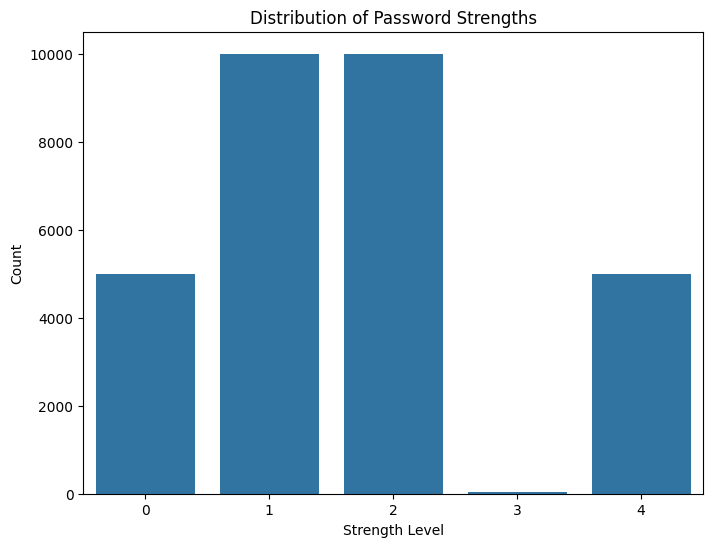

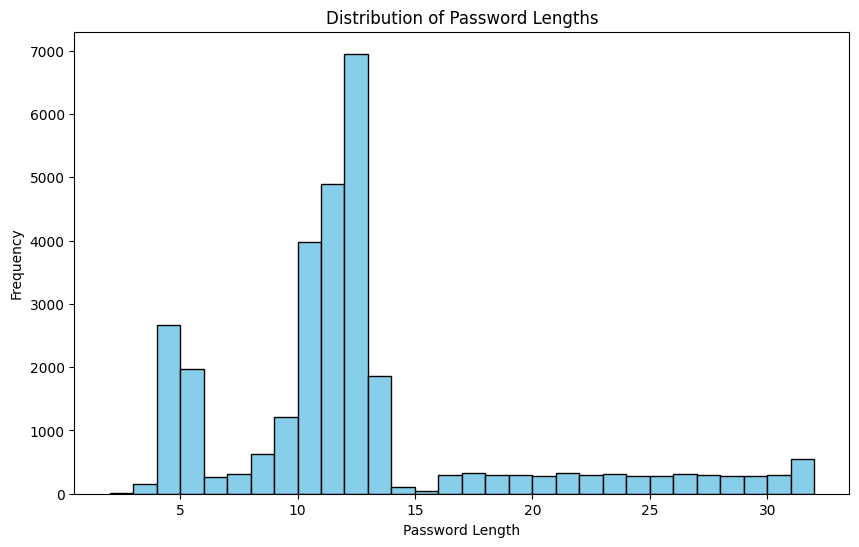

<ipython-input-2-e08049decc45>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='strength', y='password_length', data=df_password, palette="Set3")


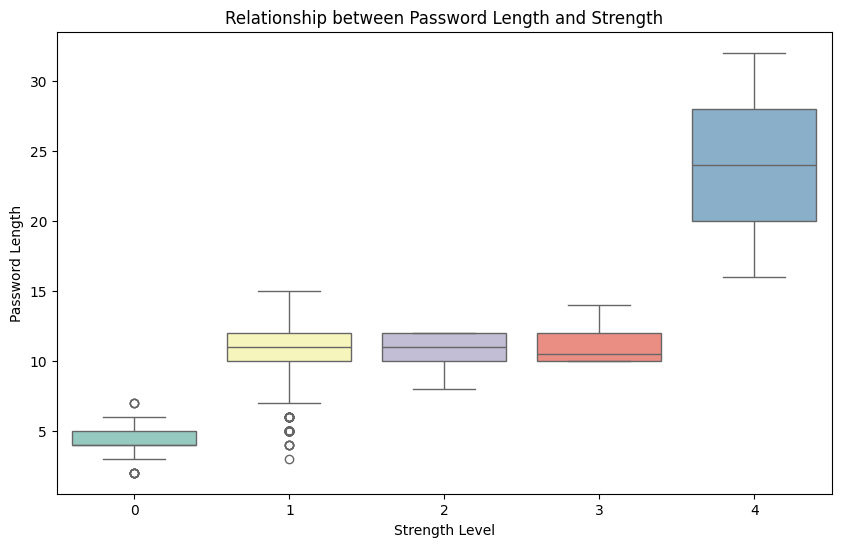

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
print(df_password.isnull().sum())

# Analyze data types
print(df_password.dtypes)

# Ensure 'strength' column is numeric (already integer)

# Investigate the distribution of password strengths
plt.figure(figsize=(8, 6))
sns.countplot(x='strength', data=df_password)
plt.title('Distribution of Password Strengths')
plt.xlabel('Strength Level')
plt.ylabel('Count')
plt.show()

# Calculate and visualize the distribution of password lengths
df_password['password_length'] = df_password['password'].str.len()
plt.figure(figsize=(10, 6))
plt.hist(df_password['password_length'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Password Lengths')
plt.xlabel('Password Length')
plt.ylabel('Frequency')
plt.show()

# Explore the relationship between password length and strength
plt.figure(figsize=(10, 6))
sns.boxplot(x='strength', y='password_length', data=df_password, palette="Set3")
plt.title('Relationship between Password Length and Strength')
plt.xlabel('Strength Level')
plt.ylabel('Password Length')
plt.show()

# Identify potential outliers (already visualized in boxplot)
# Document observations (will be done after code execution)

## Feature engineering

### Subtask:
Engineer relevant features from the password strings in the `df_password` DataFrame.


**Reasoning**:
Engineer relevant features from the password strings, such as character type counts, entropy, unique character count, consecutive character repetition, and optionally, n-grams, common subsequences, and keyboard patterns.  Combine these features with the existing DataFrame.



In [3]:
import re
import math

def calculate_entropy(password):
    if not password:
        return 0
    char_counts = {}
    for char in password:
        char_counts[char] = char_counts.get(char, 0) + 1
    entropy = 0
    for count in char_counts.values():
        probability = count / len(password)
        entropy -= probability * math.log2(probability)
    return entropy

def count_consecutive_repeats(password):
    if not password:
        return 0
    max_repeats = 0
    current_repeats = 0
    for i in range(len(password)):
        if i > 0 and password[i] == password[i-1]:
            current_repeats +=1
        else:
            max_repeats = max(max_repeats,current_repeats)
            current_repeats = 1
    max_repeats = max(max_repeats, current_repeats)
    return max_repeats

df_password['uppercase_count'] = df_password['password'].str.count(r'[A-Z]')
df_password['lowercase_count'] = df_password['password'].str.count(r'[a-z]')
df_password['digit_count'] = df_password['password'].str.count(r'[0-9]')
df_password['special_char_count'] = df_password['password'].str.count(r'[^a-zA-Z0-9]')
df_password['entropy'] = df_password['password'].apply(calculate_entropy)
df_password['unique_char_count'] = df_password['password'].apply(lambda x: len(set(x)))
df_password['consecutive_repeats'] = df_password['password'].apply(count_consecutive_repeats)

display(df_password.head())

,password,strength,password_length,uppercase_count,lowercase_count,digit_count,special_char_count,entropy,unique_char_count,consecutive_repeats
0,fofsl,0,5,0,5,0,0,1.921928,4,1
1,qabiogenous&,2,12,0,11,0,1,3.418296,11,1
2,ppppabhorrer2,1,13,0,12,1,0,2.719295,8,4
3,nmbnm,0,5,0,5,0,0,1.521928,3,1
4,acinaces2abc,1,12,0,11,1,0,2.792481,8,1


## Data splitting

### Subtask:
Split the data into training, validation, and testing sets.


**Reasoning**:
Split the data into training, validation, and testing sets with a 70/15/15 ratio, stratifying by the 'strength' column.



In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_password.drop(columns=['password', 'strength'])
y = df_password['strength']

# Split data into training and temporary sets (85/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Split temporary set into validation and testing sets (50/50 of the 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (25542, 8)
y_train shape: (25542,)
X_val shape: (2254, 8)
y_val shape: (2254,)
X_test shape: (2254, 8)
y_test shape: (2254,)


## Model training

### Subtask:
Train several machine learning models on the training data.


**Reasoning**:
Import necessary libraries and initialize the models with default hyperparameters. Then train each model on the training data.



In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models
knn = KNeighborsClassifier()
logistic_regression = LogisticRegression(max_iter=1000) # Increased max_iter to ensure convergence
decision_tree = DecisionTreeClassifier()
random_forest = RandomForestClassifier()
svm = SVC()

# Train models
models = {
    'kNN': knn,
    'Logistic Regression': logistic_regression,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest,
    'SVM': svm
}

trained_models = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    try:
      model.fit(X_train, y_train)
      trained_models[model_name] = model
      print(f"{model_name} trained successfully.")
    except Exception as e:
      print(f"An error occurred while training {model_name}: {e}")

Training kNN...
kNN trained successfully.
Training Logistic Regression...
Logistic Regression trained successfully.
Training Decision Tree...
Decision Tree trained successfully.
Training Random Forest...
Random Forest trained successfully.
Training SVM...
SVM trained successfully.


## Model optimization

### Subtask:
Optimize the hyperparameters of the trained machine learning models using the validation set.


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

# Define parameter grids for each model
param_grids = {
    'kNN': {
        'n_neighbors': range(1, 21),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2', 'none'],  # Removed 'elasticnet' and 'l1'
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']  # 'elasticnet' removed
    },
    'Decision Tree': {
        'max_depth': range(1, 31),
        'min_samples_split': range(2, 11),
        'min_samples_leaf': range(1, 6)
    },
    'Random Forest': {
        'n_estimators': range(50, 201, 10),
        'max_depth': range(10, 51, 5),
        'min_samples_split': range(2, 11)
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'gamma': ['scale', 'auto']
    }
}

best_models = {}
skf = StratifiedKFold(n_splits=5)

for model_name, model in trained_models.items():
    print(f"Tuning {model_name}...")
    try:
        grid_search = GridSearchCV(model, param_grids[model_name], scoring='accuracy', cv=skf, n_jobs=-1)
        grid_search.fit(X_val, y_val)
        best_models[model_name] = grid_search.best_estimator_
        print(f"Best hyperparameters for {model_name}: {grid_search.best_params_}")
    except Exception as e:
        print(f"An error occurred while tuning {model_name}: {e}")

Tuning kNN...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters for kNN: {'n_neighbors': 4, 'p': 1, 'weights': 'distance'}
Tuning Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
150 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
 

Best hyperparameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
Tuning Decision Tree...
Best hyperparameters for Decision Tree: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 3}
Tuning Random Forest...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 130}
Tuning SVM...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters for SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


**Reasoning**:
Optimize the hyperparameters of the trained models using GridSearchCV and print the best hyperparameters.



In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the kNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors (k)

# Train the model on the training data
knn.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_knn = knn.predict(X_val)

# Evaluate the model's performance
print("kNN Model:")
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("Classification Report:\n", classification_report(y_val, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_knn))

kNN Model:
Accuracy: 0.9751552795031055
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       375
           1       0.96      0.97      0.96       750
           2       0.96      0.97      0.97       750
           3       0.00      0.00      0.00         4
           4       1.00      1.00      1.00       375

    accuracy                           0.98      2254
   macro avg       0.78      0.79      0.79      2254
weighted avg       0.97      0.98      0.97      2254

Confusion Matrix:
 [[373   2   0   0   0]
 [  2 724  24   0   0]
 [  0  24 726   0   0]
 [  0   1   3   0   0]
 [  0   0   0   0 375]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
logistic_regression = LogisticRegression(max_iter=1000) # Increased max_iter for convergence

# Train the model
logistic_regression.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_lr = logistic_regression.predict(X_val)

# Evaluate the model
print("\nLogistic Regression Model:")
print("Accuracy:", accuracy_score(y_val, y_pred_lr))
print("Classification Report:\n", classification_report(y_val, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_lr))


Logistic Regression Model:
Accuracy: 0.9711623779946761
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       375
           1       0.96      0.96      0.96       750
           2       0.96      0.97      0.96       750
           3       0.00      0.00      0.00         4
           4       1.00      1.00      1.00       375

    accuracy                           0.97      2254
   macro avg       0.78      0.78      0.78      2254
weighted avg       0.97      0.97      0.97      2254

Confusion Matrix:
 [[371   4   0   0   0]
 [  4 719  27   0   0]
 [  0  26 724   0   0]
 [  0   1   3   0   0]
 [  0   0   0   0 375]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
decision_tree = DecisionTreeClassifier()

# Train the model
decision_tree.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_dt = decision_tree.predict(X_val)

# Evaluate the model
print("\nDecision Tree Model:")
print("Accuracy:", accuracy_score(y_val, y_pred_dt))
print("Classification Report:\n", classification_report(y_val, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_dt))


Decision Tree Model:
Accuracy: 0.9747116237799468
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       375
           1       0.96      0.97      0.96       750
           2       0.97      0.96      0.97       750
           3       1.00      0.50      0.67         4
           4       1.00      1.00      1.00       375

    accuracy                           0.97      2254
   macro avg       0.98      0.88      0.92      2254
weighted avg       0.97      0.97      0.97      2254

Confusion Matrix:
 [[374   1   0   0   0]
 [  4 727  19   0   0]
 [  0  30 720   0   0]
 [  0   1   1   2   0]
 [  0   1   0   0 374]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100) # You can adjust the number of trees

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_rf = random_forest.predict(X_val)

# Evaluate the model
print("\nRandom Forest Model:")
print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Classification Report:\n", classification_report(y_val, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_rf))


Random Forest Model:
Accuracy: 0.9773735581188997
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       375
           1       0.97      0.97      0.97       750
           2       0.97      0.97      0.97       750
           3       1.00      0.50      0.67         4
           4       1.00      1.00      1.00       375

    accuracy                           0.98      2254
   macro avg       0.99      0.89      0.92      2254
weighted avg       0.98      0.98      0.98      2254

Confusion Matrix:
 [[373   2   0   0   0]
 [  4 725  21   0   0]
 [  0  22 728   0   0]
 [  0   1   1   2   0]
 [  0   0   0   0 375]]


In [10]:
from sklearn.svm import SVC

# Initialize the SVM model
svm = SVC()

# Train the model
svm.fit(X_train, y_train)

# Make predictions on the validation data
y_pred_svm = svm.predict(X_val)

# Evaluate the model
print("\nSVM Model:")
print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print("Classification Report:\n", classification_report(y_val, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_svm))


SVM Model:
Accuracy: 0.9653948535936113
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       375
           1       0.91      0.99      0.95       750
           2       1.00      0.91      0.95       750
           3       0.00      0.00      0.00         4
           4       1.00      1.00      1.00       375

    accuracy                           0.97      2254
   macro avg       0.78      0.78      0.78      2254
weighted avg       0.97      0.97      0.96      2254

Confusion Matrix:
 [[372   3   0   0   0]
 [  5 745   0   0   0]
 [  0  66 684   0   0]
 [  0   2   2   0   0]
 [  0   0   0   0 375]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

# Assuming you already have your trained models and vectorizer
# For demonstration, let's say you have a Random Forest model as the best model
best_model = random_forest  # Replace with your best model if different
vectorizer = CountVectorizer(analyzer='char', ngram_range=(1, 3))  # Your fitted vectorizer

# Fit the vectorizer to your training data (df_password['password'])
vectorizer.fit(df_password['password']) # This line is added to fit the vectorizer

# Function to predict password strength
def predict_password_strength(password):
    # Transform the input password
    password_vector = vectorizer.transform([password])

    # Make predictions
    strength_label = best_model.predict(password_vector)[0]

    # Map the predicted label to strength levels
    strength_levels = ["Very Weak", "Weak", "Moderate", "Strong", "Very Strong", "Extremely Strong"]

    return strength_levels[strength_label]

# User input for testing
password_to_test = input("Enter a password to check its strength: ")
strength = predict_password_strength(password_to_test)
print(f"Password strength: {strength}")

NameError: name 'random_forest' is not defined

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define parameter grids for each model
param_grids = {
    'kNN': {
        'n_neighbors': range(1, 21),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2', 'elasticnet', 'none'],
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    },
    'Decision Tree': {
        'max_depth': range(1, 31),
        'min_samples_split': range(2, 11),
        'min_samples_leaf': range(1, 6)
    },
    'Random Forest': {
        'n_estimators': range(50, 201, 10),
        'max_depth': range(10, 51, 5),
        'min_samples_split': range(2, 11)
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'gamma': ['scale', 'auto']
    }
}

best_models = {}
for model_name, model in trained_models.items():
    print(f"Tuning {model_name}...")
    try:
        grid_search = GridSearchCV(model, param_grids[model_name], scoring='accuracy', cv=5, n_jobs=-1)
        grid_search.fit(X_val, y_val)
        best_models[model_name] = grid_search.best_estimator_
        print(f"Best hyperparameters for {model_name}: {grid_search.best_params_}")
    except Exception as e:
        print(f"An error occurred while tuning {model_name}: {e}")

Tuning kNN...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters for kNN: {'n_neighbors': 4, 'p': 1, 'weights': 'distance'}
Tuning Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
390 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *a

Best hyperparameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
Tuning Decision Tree...
Best hyperparameters for Decision Tree: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuning Random Forest...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 170}
Tuning SVM...


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best hyperparameters for SVM: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [1]:
import numpy as np
from scipy.sparse import hstack, csr_matrix

def _extract_features(password, vectorizer):
    """Extracts TF-IDF and engineered features from a single password."""
    # Ensure password is a string
    if not isinstance(password, str):
        password = str(password)

    # 1. TF-IDF Features
    # Pass the password as a list to get a (1, 5000) sparse matrix
    tfidf_features = vectorizer.transform([password])  # Shape: (1, 5000)

    # 2. Engineered Features
    length = len(password)
    uppercase = sum(c.isupper() for c in password)
    lowercase = sum(c.islower() for c in password)
    digits = sum(c.isdigit() for c in password)
    special_chars = sum(not c.isalnum() for c in password)

    # Calculate ratios, avoiding division by zero
    if length > 0:
        uppercase_ratio = uppercase / length
        lowercase_ratio = lowercase / length
        digit_ratio = digits / length
        special_char_ratio = special_chars / length
    else:
        uppercase_ratio = 0
        lowercase_ratio = 0
        digit_ratio = 0
        special_char_ratio = 0

    # Create a 2D array for engineered features, shape: (1, 9)
    engineered_features = np.array([[length, uppercase, lowercase, digits, special_chars,
                                    uppercase_ratio, lowercase_ratio, digit_ratio, special_char_ratio]])

    # Convert to sparse matrix
    engineered_features_sparse = csr_matrix(engineered_features)  # Shape: (1, 9)

    # 3. Combine Features
    combined_features = hstack([tfidf_features, engineered_features_sparse])  # Shape: (1, 5009)

    return combined_features



In [2]:
import ipywidgets as widgets
from IPython.display import display

password_input = widgets.Text(
    placeholder='Enter your password here',
    description='Password:',
    disabled=False
)

output = widgets.Output()

def on_submit(change):
    with output:
        output.clear_output()
        password = change['new']
        try:
            knn_prediction = predict_password_strength_knn(password, vectorizer, knn_model)
            rf_prediction = predict_password_strength_rf(password, vectorizer, best_rf_model)
            combined_prediction = round((0.4 * knn_prediction) + (0.6 * rf_prediction))
            print(f"Password: {password}")
            print(f"kNN Prediction: {knn_prediction}")
            print(f"Random Forest Prediction: {rf_prediction}")
            print(f"Combined Prediction: {combined_prediction}")
        except Exception as e:
            print(f"Error: {e}")

password_input.observe(on_submit, names='value')
display(password_input, output)

Text(value='', description='Password:', placeholder='Enter your password here')

Output()